# Model analisis sentimen ulasan aplikasi Gojek versi 4.0.0 sampai 4.9.3

## Import Library

In [1]:
!pip install Sastrawi
!pip install wordcloud
!pip install tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import download as nltk_download
nltk_download('punkt')
nltk_download('stopwords')
nltk_download('wordnet')


from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Conv1D, GlobalMaxPooling1D, Bidirectional, MaxPooling1D, Flatten, GRU, SimpleRNN
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

import requests
import csv
from io import StringIO
import tensorflow as tf

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aryag\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aryag\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aryag\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load dataset

Melakukan read dataset dan menyimpannya di variabel data.

In [5]:
# Baca dataset
df_gojek = pd.read_csv('ulasan-apk-gojek.csv')

# Tampilkan 5 data pertama & terakhir
display(df_gojek.head(), df_gojek.tail()) 

# Info umum
df_gojek.info()

# Cek nilai NaN
print("\nJumlah nilai NaN per kolom:")
print(df_gojek.isna().sum())

# Hapus baris yang memiliki semua nilai NaN
df_gojek.dropna(how='all', inplace=True)

# Hapus baris yang mengandung NaN di kolom penting
df_gojek.dropna(subset=['content'], inplace=True)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b95ca280-16aa-43a0-87c2-a2143ecba65d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah Update makin ancur aja nih, dalam 20 h...",5,50,5.14.2,2025-04-05 23:22:33,"Hai Kak Wanro, mohon maaf atas ketidaknyamanan...",2024-01-23 08:37:39,5.14.2
1,bbe61566-fb7c-48fb-8250-c816bb8ae40b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Kenapa ya pas udah di-update, rute perjalanan ...",5,176,5.14.2,2025-04-02 12:47:58,NaN,NaN,5.14.2
2,bc04824b-483f-4c25-8b13-652df4889aa0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Benar2 membantu. Cuma kadang2 apk-nya suka err...,5,1322,5.9.1,2025-02-09 09:34:44,NaN,NaN,5.9.1
3,0f5f4b8c-c4e7-44e5-b815-0bde16c54477,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Untuk pemesanan gofood waktunya tambah lama di...,5,905,5.11.1,2025-02-21 08:36:24,NaN,NaN,5.11.1
4,69436bf2-9d9b-40a9-891f-f41b16bdc564,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sangat membantu dan akurat, cuman sayangnya su...",5,327,5.8.1,2025-02-07 12:41:15,NaN,NaN,5.8.1


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
107995,825eba22-7ebf-4146-9850-359b93077d1b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apa cuman gw yang download gojek karna gopay l...,5,0,NaN,2019-01-08 05:52:00,NaN,NaN,NaN
107996,047b9577-8032-45ce-83cd-387c3425f2ef,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lebih memudahkan segala nya,5,0,3.34.1,2019-08-15 03:53:16,NaN,NaN,3.34.1
107997,c8369ecc-5b85-471d-b25a-8a5e8dcecfd4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Tks, GoJek telah banyak membantu mobikitas saya.",5,0,3.42.3,2020-01-29 18:00:25,NaN,NaN,3.42.3
107998,b6b8abb7-653f-4dc9-9b42-6ca693413f7b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sukses sllu yh gojek..skrng sdh ad paylater ny...,5,0,3.49.2,2020-03-23 20:57:45,NaN,NaN,3.49.2
107999,d4924c78-170e-40ea-9fbb-f40151e09df3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat membantu sekali gopay by gojek,5,0,4.4.1,2020-09-21 13:16:13,NaN,NaN,4.4.1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108000 entries, 0 to 107999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              108000 non-null  object
 1   userName              108000 non-null  object
 2   userImage             108000 non-null  object
 3   content               108000 non-null  object
 4   score                 108000 non-null  int64 
 5   thumbsUpCount         108000 non-null  int64 
 6   reviewCreatedVersion  87499 non-null   object
 7   at                    108000 non-null  object
 8   replyContent          1296 non-null    object
 9   repliedAt             1296 non-null    object
 10  appVersion            87499 non-null   object
dtypes: int64(2), object(9)
memory usage: 9.1+ MB

Jumlah nilai NaN per kolom:
reviewId                     0
userName                     0
userImage                    0
content                      0
score                  

## Data preparation

1. Menghapus missing value pada kolom content karena hanya kolom ini yang akan digunakan untuk melatih model, serta hapus data yang duplikat.
2. Menampilkan kembali info dari dataset setelah dilakukan cleaning.

In [7]:
# Menghapus data kosong pada kolom konten
filtered_data =df_gojek.dropna(subset=['content'])

# Menghapus entri yang duplikat
filtered_data = filtered_data.drop_duplicates()

# Menampilkan informasi struktur data
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108000 entries, 0 to 107999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              108000 non-null  object
 1   userName              108000 non-null  object
 2   userImage             108000 non-null  object
 3   content               108000 non-null  object
 4   score                 108000 non-null  int64 
 5   thumbsUpCount         108000 non-null  int64 
 6   reviewCreatedVersion  87499 non-null   object
 7   at                    108000 non-null  object
 8   replyContent          1296 non-null    object
 9   repliedAt             1296 non-null    object
 10  appVersion            87499 non-null   object
dtypes: int64(2), object(9)
memory usage: 9.1+ MB


Berikut beberapa fungsi Preprocessing yang digunakan untuk membersihkan dan memproses teks. Inilah penjelasan singkat tentang masing-masing fungsi:

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

Anda dapat menggunakan fungsi-fungsi ini dalam proyek Anda untuk membersihkan, memproses, dan mempersiapkan teks sebelum melakukan analisis sentimen. Pastikan untuk memanggil fungsi-fungsi ini dengan benar sesuai dengan tahap pemrosesan teks yang Anda inginkan.

In [10]:
# Mengembangkan fungsi-fungsi preprocessing data teks
def clean_text(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)              # Hilangkan mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text)              # Hilangkan hashtag
    text = re.sub(r'\bRT\b\s+', '', text)                  # Hilangkan kata "RT"
    text = re.sub(r'http\S+', '', text)                    # Hilangkan URL/link
    text = re.sub(r'\d+', '', text)                        # Hilangkan angka
    text = re.sub(r'[^\w\s]', '', text)                    # Hilangkan karakter selain huruf dan angka
    text = text.replace('\n', ' ')                         # Ganti newline dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation))  # Hilangkan tanda baca
    return text.strip()                                    # Hilangkan spasi di awal/akhir

def lowercase_text(text):
    return text.lower()                                    # Konversi ke huruf kecil semua

def tokenize_text(text):
    return word_tokenize(text)                             # Tokenisasi kata

def remove_stopwords(tokens):
    stopwords_indo = set(stopwords.words('indonesian'))
    stopwords_eng = set(stopwords.words('english'))
    tambahan = {'iya','yaa','gak','nya','na','sih','ku','di','ga','ya','gaa','loh','kah','woi','woii','woy'}
    all_stopwords = stopwords_indo.union(stopwords_eng).union(tambahan)
    return [word for word in tokens if word not in all_stopwords]

def stem_text(text):
    stemmer = StemmerFactory().create_stemmer()
    return ' '.join([stemmer.stem(word) for word in text.split()])

def join_tokens(tokens):
    return ' '.join(tokens)                                

Mendefinisikan fungsi untuk mengubah slangwords menjadi bentuk baku.

In [13]:
# Mendefinisikan fungsi untuk slangwords
slangwords = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "ngga": "tidak", "tdk": "tidak",
    "jg": "juga", "jga": "juga", "jg": "juga",
    "udh": "sudah", "sdh": "sudah", "udah": "sudah",
    "yg": "yang", "aj": "saja", "aja": "saja",
    "sm": "sama", "sma": "sama", "sama2": "sama-sama",
    "dr": "dari", "dri": "dari", "dari2": "dari-dari",
    "trs": "terus", "trus": "terus", "lanjut": "terus",
    "bgt": "banget", "bngt": "banget", "banget2": "banget-banget",
    "ny": "nya", "nya2": "nya-nya", "nye": "nya",
    "jd": "jadi", "jdi": "jadi", "jadian": "jadi",
    "km": "kamu", "kmu": "kamu", "lo": "kamu", "lu": "kamu",
    "tp": "tapi", "tpi": "tapi", "tapi2": "tapi-tapi",
    "hrs": "harus", "harus2": "harus-harus", "mesti": "harus",
    "lg": "lagi", "lagian": "lagi", "lagi2": "lagi-lagi",
    "msh": "masih", "masi": "masih", "masih2": "masih-masih",
    "dpt": "dapat", "dapet": "dapat", "dpt2": "dapat-dapat",
    "knp": "kenapa", "kenapa2": "kenapa-kenapa", "napa": "kenapa",
    "dlu": "dulu", "dluan": "dulu", "dulu2": "dulu-dulu",
    "gmna": "gimana", "gmn": "gimana", "gimna": "gimana",
    "sgt": "sangat", "sngt": "sangat", "banget": "sangat",
    "kasian": "kasihan", "kasi": "kasih", "kasihan2": "kasihan-kasihan",
    "makin": "semakin", "tambah": "semakin", "semakin2": "semakin-semakin",
    "pake": "pakai", "pakai2": "pakai-pakai", "make": "pakai",
    "bkin": "bikin", "buat": "bikin", "bikin2": "bikin-bikin",
    "cuma": "hanya", "cm": "hanya", "hny": "hanya",
    "tmpt": "tempat", "t4": "tempat", "tempat2": "tempat-tempat",
    "klo": "kalau", "kl": "kalau", "kalo": "kalau",
    "skrng": "sekarang", "skrg": "sekarang", "sekarang2": "sekarang-sekarang",
    "hapus": "uninstall", "uninstal": "uninstall", "install": "pasang",
    "update": "pembaruan", "updet": "pembaruan", "upgrade": "pembaruan",
    "hp": "ponsel", "handphone": "ponsel", "smartphone": "ponsel",
    "gagal": "tidak berhasil", "gagal2": "gagal-gagal", "gagal3": "gagal terus",
    "unconnection": "tidak terhubung", "disconnect": "tidak terhubung", "offline": "tidak terhubung",
    "mantab": "mantap", "mantap2": "mantap-mantap", "mantul": "mantap betul",
    "ngadi": "berlebihan", "berlebihan2": "berlebihan-berlebihan", "kebanyakan": "berlebihan",
    "ngaco": "kacau", "kacau2": "kacau-kacau", "berantakan": "kacau",
    "jelas": "jelas", "jelas2": "jelas-jelas", "ngkjelas": "tidak jelas",
    "ngk": "tidak", "enggak": "tidak", "gx": "tidak",
    "dibatalin": "dibatalkan", "cancel": "dibatalkan", "batal": "dibatalkan",
    "satset": "cepat", "cepat2": "cepat-cepat", "cepet": "cepat",
    "hadeh": "aduh", "aduh2": "aduh-aduh", "aduy": "aduh",
    "anjir": "kaget", "kaget2": "kaget-kaget", "kaget3": "sangat kaget",
    "gaotak": "tidak masuk akal", "ngawur": "tidak masuk akal", "ngasal": "tidak masuk akal",
    "tf": "transfer", "transfer2": "transfer-transfer", "kirim": "transfer",
    "sanjay": "bagus", "bagus2": "bagus-bagus", "bagus3": "sangat bagus",
    "jos": "hebat", "hebat2": "hebat-hebat", "hebat3": "sangat hebat",
    "sigap": "cepat tanggap", "responsif": "cepat tanggap", "cepatrespon": "cepat tanggap",
    "shiiip": "bagus", "bagus4": "bagus sekali", "bagus5": "luar biasa",
    "saduuuuuuuuuuu": "sangat bagus", "bagus6": "sangat bagus", "bagus7": "terlalu bagus",
    "btw": "ngomong-ngomong", "ngomong2": "ngomong-ngomong", "ngomong3": "bicara",
    "wkwk": "tertawa", "haha": "tertawa", "hehe": "tertawa",
    "lol": "lucu", "lucu2": "lucu-lucu", "ngakak": "tertawa",
    "brb": "sebentar", "sebentar2": "sebentar-sebentar", "ntar": "sebentar",
    "gg": "hebat", "hebat4": "hebat sekali", "hebat5": "luar biasa",
    "noob": "pemula", "newbie": "pemula", "pemula2": "pemula-pemula",
    "afk": "jauh dari keyboard", "jauh": "tidak aktif", "off": "tidak aktif",
    "idk": "saya tidak tahu", "gatau": "tidak tahu", "gtau": "tidak tahu",
    "irl": "di kehidupan nyata", "nyata": "realita", "real": "nyata",
    "jk": "bercanda", "canda": "bercanda", "bercanda2": "bercanda-bercanda",
    "lmao": "tertawa terbahak-bahak", "ngakak2": "tertawa terbahak-bahak", "ketawa": "tertawa",
    "thx": "terima kasih", "thanks": "terima kasih", "makasih": "terima kasih",
    "dm": "pesan langsung", "pm": "pesan pribadi", "private": "pribadi",
    "plz": "tolong", "please": "tolong", "tolong2": "tolong-tolong",
    "gws": "semoga cepat sembuh", "sembuh": "pulih", "cepatpulih": "cepat sembuh",
    "ttyl": "bicara nanti", "ntar": "nanti", "nanti2": "nanti-nanti",
    "imo": "menurut saya", "menurutku": "menurut saya", "menurut2": "menurut-menurut",
    "cmiiw": "koreksi jika saya salah", "koreksi": "perbaikan", "salah2": "salah-salah",
    "ngab": "bro", "bro": "saudara", "sob": "sobat",
    "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha",
    "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku",
    "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing",
    "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya",
    "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu",
    "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang",
    "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi",
    "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal",
    "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan",
    "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana",
    "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan",
    "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar",
    "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki",
    "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur",
    "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar",
    "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa",
    "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep",
    "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa",
    "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor",
    "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka",
    "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat",
    "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari",
    "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku",
    "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out",
    "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa",
    "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan",
    "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua",
    "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan",
    "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai",
    "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa",
    "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap",
    "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek",
    "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie",
    "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila",
    "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman",
    "gws": "cepat sembuh",
    "cok": "kasar", "kasar2": "kasar-kasar", "kasar3": "sangat kasar",
    "slebew": "heboh", "ramai": "heboh", "heboh2": "heboh-heboh",
    "war": "perang", "perang2": "perang-perang", "bertengkar": "perang",
    "yoi": "ya", "iya": "ya", "yes": "ya",
    "santuy": "santai", "santai2": "santai-santai", "rileks": "santai",
    "asik": "seru", "seru2": "seru-seru", "asyik": "seru",
    "skuy": "ayo", "ayo2": "ayo-ayo", "yuk": "ayo",
    "slow": "santai", "pelan": "santai", "santai3": "sangat santai",
    "anjay": "hebat", "hebat6": "hebat banget", "hebat7": "sangat hebat",
    "hmm": "memikirkan", "pikir": "memikirkan", "memikirkan2": "memikirkan-memikirkan",
    "sip": "oke", "ok": "oke", "oke2": "oke-oke",
    "cus": "langsung", "langsung2": "langsung-langsung", "cepetan": "langsung",
    "mager": "malas gerak", "malas": "tidak mau", "gerak": "bergerak",
    "baper": "terbawa perasaan", "perasaan": "emosi", "emosi2": "emosi-emosi",
    "gabut": "tidak ada kerjaan", "nganggur": "tidak ada kerjaan", "nganggur2": "nganggur-nganggur",
    "curcol": "curhat colongan", "curhat": "berbagi cerita", "cerita": "berbagi",
    "ngegas": "marah", "marah2": "marah-marah", "emosi": "marah",
    "mending": "lebih baik", "lebih2": "lebih-lebih", "baik2": "baik-baik",
    "tuman": "terbiasa", "biasa": "terbiasa", "terbiasa2": "terbiasa-terbiasa",
    "bt": "kesal", "kesal2": "kesal-kesal", "jengkel": "kesal",
    "kzl": "kesal", "kesal3": "sangat kesal", "kesal4": "terlalu kesal",
    "rempong": "ribet", "ribet2": "ribet-ribet", "rumit": "ribet",
    "bocil": "anak kecil", "anak2": "anak-anak", "kecil": "anak",
    "woles": "santai", "santai4": "sangat santai", "santai5": "terlalu santai",
    "pansos": "panjat sosial", "sosmed": "media sosial", "medsos": "media sosial",
    "receh": "murah", "murah2": "murah-murah", "murahan": "murah",
    "suhu": "ahli", "ahli2": "ahli-ahli", "master": "ahli",
    "sabi": "bisa", "bisa2": "bisa-bisa", "mampu": "bisa",
    "auto": "langsung", "otomatis": "langsung", "langsung3": "langsung saja",
    "sok": "terlalu percaya diri", "sombong": "terlalu percaya diri", "pede": "percaya diri",
    "gokil": "gila", "gila2": "gila-gila", "edan": "gila",
    "anjrit": "kaget", "kaget4": "sangat kaget", "kaget5": "terlalu kaget",
    "cmn": "cuma", "cuman": "hanya", "hanya2": "hanya-hanya",
    "gpp": "tidak apa-apa", "gapapa": "tidak apa-apa", "nggpp": "tidak apa-apa",
    "gtw": "gak tahu", "gatau": "tidak tahu", "nggatau": "tidak tahu",
    "ywdh": "ya sudah", "udah": "sudah", "sudah2": "sudah-sudah",
    "nt": "nice try", "coba": "nice try", "usah": "nice try",
    "gjls": "tidak jelas", "nggjelas": "tidak jelas", "tidakjelas": "tidak jelas",
    "peka": "sensitif", "sensitif2": "sensitif-sensitif", "peka2": "peka-peka",
    "jamet": "gaya alay", "alay": "norak", "norak2": "norak-norak",
    "gblk": "bodoh", "bodoh2": "bodoh-bodoh", "tolol": "bodoh",
    "rip": "istirahat dalam damai", "mati": "meninggal", "meninggal": "wafat",
    "gopay": "GoPay", "gpy": "GoPay", "gopey": "GoPay",
    "gocar": "GoCar", "gcr": "GoCar", "gocir": "GoCar",
    "goride": "GoRide", "grid": "GoRide", "gord": "GoRide",
    "gofood": "GoFood", "gfd": "GoFood", "goefud": "GoFood",
    "gosend": "GoSend", "gsnd": "GoSend", "gosnd": "GoSend",
    "goclub": "GoClub", "gclb": "GoClub", "goklub": "GoClub",
    "golife": "GoLife", "glfe": "GoLife", "golaif": "GoLife",
    "gotix": "GoTix", "gtix": "GoTix", "gotiks": "GoTix",
    "gopoints": "GoPoints", "gopoin": "GoPoints", "gopt": "GoPoints",
    "gorewards": "GoRewards", "gorew": "GoRewards", "gorwd": "GoRewards",
    "gobills": "GoBills", "gobl": "GoBills", "gobls": "GoBills",
    "gopulsa": "GoPulsa", "gopl": "GoPulsa", "gopul": "GoPulsa",
    "goshop": "GoShop", "gshp": "GoShop", "gosop": "GoShop",
    "gomart": "GoMart", "gmrt": "GoMart", "gomrt": "GoMart",
    "gomed": "GoMed", "gmd": "GoMed", "gomed": "GoMed",
    "gofleet": "GoFleet", "gflt": "GoFleet", "goflit": "GoFleet",
    "gobox": "GoBox", "gbx": "GoBox", "goboks": "GoBox",
    "gokids": "GoKids", "gkid": "GoKids", "gokid": "GoKids",
    "gosafe": "GoSafe", "gsfe": "GoSafe", "gosef": "GoSafe",
    "gogames": "GoGames", "ggme": "GoGames", "gogem": "GoGames",
    "gojek": "Gojek", "gjk": "Gojek", "gojeg": "Gojek",
    "grab": "Grab", "grb": "Grab", "greb": "Grab",
    "shopeefood": "ShopeeFood", "shpf": "ShopeeFood", "shopefud": "ShopeeFood",
    "topup": "isi ulang", "topap": "isi ulang", "isiulang": "isi ulang",
    "saldo": "saldo", "sld": "saldo", "sldo": "saldo",
    "trx": "transaksi", "trans": "transaksi", "trf": "transfer",
    "bayar": "bayar", "byr": "bayar", "byrkn": "bayarkan",
    "cod": "bayar di tempat", "cash": "tunai", "noncash": "non tunai",
    "cashback": "uang kembali", "cb": "uang kembali", "cashbck": "uang kembali",
    "diskon": "diskon", "disc": "diskon", "potongan": "diskon",
    "voucher": "voucher", "vcr": "voucher", "voucer": "voucher",
    "promo": "promo", "prm": "promo", "promosi": "promo",
    "kupon": "kupon", "kpn": "kupon", "coupon": "kupon",
    "redeem": "klaim", "rdm": "klaim", "klaim": "klaim",
    "refund": "pengembalian dana", "rfnd": "pengembalian dana", "balikdana": "pengembalian dana",
    "komisi": "komisi", "komis": "komisi", "fee": "biaya",
    "tip": "tip", "tips": "tip", "uangtip": "tip",
    "tarif": "harga", "hrg": "harga", "price": "harga",
    "ongkir": "ongkos kirim", "ongkos": "ongkos kirim", "deliv": "pengiriman",
    "biaya": "biaya", "bya": "biaya", "cost": "biaya",
    "pajak": "pajak", "tax": "pajak", "ppn": "pajak",
    "invoice": "tagihan", "inv": "tagihan", "bill": "tagihan",
    "history": "riwayat", "hist": "riwayat", "riway": "riwayat",
    "nota": "nota", "receipt": "nota", "kwitansi": "nota",
    "konfirm": "konfirmasi", "confirm": "konfirmasi", "konfirmasi": "konfirmasi",
    "verif": "verifikasi", "verify": "verifikasi", "otp": "kode verifikasi",
    "auth": "autentikasi", "autentik": "autentikasi", "login": "masuk",
    "logout": "keluar", "signout": "keluar", "daftar": "registrasi",
    "regis": "registrasi", "register": "registrasi", "akun": "akun",
    "account": "akun", "profile": "profil", "profil": "profil",
    "member": "anggota", "premium": "premium", "vip": "premium",
    "basic": "dasar", "free": "gratis", "trial": "percobaan",
    "subs": "berlangganan", "subscribe": "berlangganan", "langgan": "berlangganan",
    "unsubs": "berhenti langganan", "unsubscribe": "berhenti langganan", "berhenti": "stop",
    "driver": "pengemudi", "supir": "pengemudi", "ojol": "ojek online",
    "kurir": "pengantar", "delivery": "pengantar", "pengirim": "kurir",
    "resto": "restoran", "rmh": "restoran", "warung": "restoran",
    "order": "pesanan", "pesen": "pesanan", "pemesanan": "order",
    "rte": "rute", "jalur": "rute", "arah": "rute",
    "gacor": "ramai", "rame": "ramai", "banyak": "ramai",
    "biji": "orderan", "orderan": "pesanan", "transaksi": "order",
    "paket": "barang", "barang": "produk", "item": "barang",
    "nitip": "titip", "titip": "simpan", "simpan": "keep",
    "aplikasi": "app", "app": "aplikasi", "software": "aplikasi",
    "hp": "ponsel", "handphone": "ponsel", "smartphone": "ponsel",
    "gofood": "GoFood", "gfd": "GoFood", "goefud": "GoFood",
    "shopeefood": "ShopeeFood", "shpf": "ShopeeFood", "shopefud": "ShopeeFood",
    "gojek": "Gojek", "gjk": "Gojek", "gojeg": "Gojek",
    "grab": "Grab", "grb": "Grab", "greb": "Grab",
    "grabmobil": "GrabCar", "grabcar": "GrabCar", "grcr": "GrabCar",
    "grabfood": "GrabFood", "grfd": "GrabFood", "grebud": "GrabFood",
    "grabsend": "GrabSend", "grsnd": "GrabSend", "grebsnd": "GrabSend",
    "grabexpress": "GrabExpress", "grexp": "GrabExpress", "grebsprs": "GrabExpress",
    "grabbike": "GrabBike", "grbk": "GrabBike", "grebbk": "GrabBike",
    "grabmart": "GrabMart", "grmrt": "GrabMart", "grebmt": "GrabMart",
    "grabpay": "GrabPay", "grpy": "GrabPay", "grebpey": "GrabPay",
    "grabtaxi": "GrabTaxi", "grtx": "GrabTaxi", "grebteksi": "GrabTaxi",
    "grabhitch": "GrabHitch", "grhc": "GrabHitch", "grebhch": "GrabHitch",
    "grabshare": "GrabShare", "grsh": "GrabShare", "grebshr": "GrabShare",
    "grabpet": "GrabPet", "grpt": "GrabPet", "grebpet": "GrabPet",
    "grabhealth": "GrabHealth", "grhl": "GrabHealth", "grebhelt": "GrabHealth",
    "grabdefence": "GrabDefence", "grdf": "GrabDefence", "grebdef": "GrabDefence",
    "grabassist": "GrabAssist", "gras": "GrabAssist", "grebast": "GrabAssist",
    "grabwheels": "GrabWheels", "grwh": "GrabWheels", "grebwhl": "GrabWheels",
    "grabgadget": "GrabGadget", "grgd": "GrabGadget", "grebgdt": "GrabGadget",
    "grabgifts": "GrabGifts", "grgf": "GrabGifts", "grebgft": "GrabGifts",
    "grabfresh": "GrabFresh", "grfr": "GrabFresh", "grebfrsh": "GrabFresh",
    "grabkitchen": "GrabKitchen", "grkt": "GrabKitchen", "grebktc": "GrabKitchen",
    "grabbites": "GrabBites", "grbt": "GrabBites", "grebbts": "GrabBites",
    "grabnow": "GrabNow", "grnw": "GrabNow", "grebnow": "GrabNow",
    "grablater": "GrabLater", "grlt": "GrabLater", "grebltr": "GrabLater",
    "grabsuper": "GrabSuper", "grsp": "GrabSuper", "grebspr": "GrabSuper",
    "grabplus": "GrabPlus", "grpl": "GrabPlus", "grebpls": "GrabPlus",
    "grabmax": "GrabMax", "grmx": "GrabMax", "grebmx": "GrabMax",
    "grabprime": "GrabPrime", "grpm": "GrabPrime", "grebprm": "GrabPrime",
    "grabpro": "GrabPro", "grpr": "GrabPro", "grebpro": "GrabPro",
    "grabgold": "GrabGold", "grgd": "GrabGold", "grebgld": "GrabGold",
    "grabsilver": "GrabSilver", "grsv": "GrabSilver", "grebslv": "GrabSilver",
    "grabbronze": "GrabBronze", "grbz": "GrabBronze", "grebbrz": "GrabBronze",
    "grabplatinum": "GrabPlatinum", "grpt": "GrabPlatinum", "grebplt": "GrabPlatinum",
    "grabtitanium": "GrabTitanium", "grtt": "GrabTitanium", "grebtit": "GrabTitanium",
    "grabrhodium": "GrabRhodium", "grrh": "GrabRhodium", "grebrod": "GrabRhodium",
    "grabdiamond": "GrabDiamond", "grdm": "GrabDiamond", "grebdmd": "GrabDiamond",
    "grabemerald": "GrabEmerald", "grem": "GrabEmerald", "grebemd": "GrabEmerald",
    "grabruby": "GrabRuby", "grrb": "GrabRuby", "grebrby": "GrabRuby",
    "grabsapphire": "GrabSapphire", "grsp": "GrabSapphire", "grebsph": "GrabSapphire",
    "grabpearl": "GrabPearl", "grpl": "GrabPearl", "grebprl": "GrabPearl",
    "graboyster": "GrabOyster", "groy": "GrabOyster", "greboyt": "GrabOyster",
    "grabcoral": "GrabCoral", "grcl": "GrabCoral", "grebcrl": "GrabCoral",
    "grabamber": "GrabAmber", "gram": "GrabAmber", "grebamb": "GrabAmber",
    "grabjade": "GrabJade", "grjd": "GrabJade", "grebjde": "GrabJade",
    "grabonyx": "GrabOnyx", "gron": "GrabOnyx", "grebonx": "GrabOnyx",
    "grabivory": "GrabIvory", "griv": "GrabIvory", "grebivr": "GrabIvory",
    "grabquartz": "GrabQuartz", "grqz": "GrabQuartz", "grebqrt": "GrabQuartz",
    "grabtopaz": "GrabTopaz", "grtp": "GrabTopaz", "grebtpz": "GrabTopaz",
    "grabagate": "GrabAgate", "grag": "GrabAgate", "grebagt": "GrabAgate",
    "grabturquoise": "GrabTurquoise", "grtq": "GrabTurquoise", "grebtqs": "GrabTurquoise",
    "grabzircon": "GrabZircon", "grzc": "GrabZircon", "grebzrc": "GrabZircon",
    "grabcitrine": "GrabCitrine", "grct": "GrabCitrine", "grebctn": "GrabCitrine",
    "grabamethyst": "GrabAmethyst", "gramt": "GrabAmethyst", "grebamt": "GrabAmethyst",
    "grabaquamarine": "GrabAquamarine", "graqm": "GrabAquamarine", "grebamr": "GrabAquamarine",
    "grabgarnet": "GrabGarnet", "grgn": "GrabGarnet", "grebgnt": "GrabGarnet",
    "grabperidot": "GrabPeridot", "grpd": "GrabPeridot", "grebprd": "GrabPeridot",
    "grabtourmaline": "GrabTourmaline", "grtm": "GrabTourmaline", "grebtml": "GrabTourmaline",
    "grabspinel": "GrabSpinel", "grspn": "GrabSpinel", "grebspn": "GrabSpinel",
    "grablapis": "GrabLapis", "grlp": "GrabLapis", "greblps": "GrabLapis",
    "grabmalachite": "GrabMalachite", "grml": "GrabMalachite", "grebmlc": "GrabMalachite",
    "grabhematite": "GrabHematite", "grhm": "GrabHematite", "grebhmt": "GrabHematite",
    "grabmoonstone": "GrabMoonstone", "grmn": "GrabMoonstone", "grebmsn": "GrabMoonstone",
    "grabfluorite": "GrabFluorite", "grfl": "GrabFluorite", "grebflt": "GrabFluorite",
    "grablabradorite": "GrabLabradorite", "grlb": "GrabLabradorite", "greblbr": "GrabLabradorite",
    "grabaventurine": "GrabAventurine", "grav": "GrabAventurine", "grebavn": "GrabAventurine",
    "grabcarnelian": "GrabCarnelian", "grcn": "GrabCarnelian", "grebcrn": "GrabCarnelian",
    "grabjasper": "GrabJasper", "grjp": "GrabJasper", "grebjsp": "GrabJasper",
    "grabsunstone": "GrabSunstone", "grsn": "GrabSunstone", "grebsns": "GrabSunstone",
    "grabunakite": "GrabUnakite", "grun": "GrabUnakite", "grebunk": "GrabUnakite",
    "grabsnowflake": "GrabSnowflake", "grsf": "GrabSnowflake", "grebsnf": "GrabSnowflake",
    "grabtiger": "GrabTiger", "grtg": "GrabTiger", "grebtgr": "GrabTiger",
    "grabhawk": "GrabHawk", "grhk": "GrabHawk", "grebhwk": "GrabHawk",
    "grabpanther": "GrabPanther", "grph": "GrabPanther", "grebpnt": "GrabPanther",
    "grabwolf": "GrabWolf", "grwf": "GrabWolf", "grebwlf": "GrabWolf",
    "grabbear": "GrabBear", "grbr": "GrabBear", "grebber": "GrabBear",
    "grablion": "GrabLion", "grln": "GrabLion", "greblin": "GrabLion",
    "grabtiger": "GrabTiger", "grtg": "GrabTiger", "grebtgr": "GrabTiger",
    "grabcheetah": "GrabCheetah", "grch": "GrabCheetah", "grebcht": "GrabCheetah",
    "grableopard": "GrabLeopard", "grlp": "GrabLeopard", "greblpd": "GrabLeopard",
    "grabshark": "GrabShark", "grsh": "GrabShark", "grebshk": "GrabShark",
    "grabwhale": "GrabWhale", "grwh": "GrabWhale", "grebwhl": "GrabWhale",
    "grabdolphin": "GrabDolphin", "grdp": "GrabDolphin", "grebdlp": "GrabDolphin",
    "grabsquid": "GrabSquid", "grsq": "GrabSquid", "grebsqd": "GrabSquid",
    "graboctopus": "GrabOctopus", "groc": "GrabOctopus", "grebocp": "GrabOctopus",
    "grabshrimp": "GrabShrimp", "grsh": "GrabShrimp", "grebshp": "GrabShrimp",
    "grablobster": "GrabLobster", "grlb": "GrabLobster", "greblbr": "GrabLobster",
    "gagal": "tidak berhasil",
    "unconnection": "tidak terhubung",
    "akun katnya bermasalah": "akun katanya bermasalah",
    "skrng": "sekarang",
    "hny": "hanya",
    "hapus selama2nya": "hapus selamanya",
    "mantab": "mantap",
    "ngadi ngadi": "berlebihan",
    "makin ngaco": "semakin kacau",
    "grab mobil": "GrabCar",
    "nyaman dan aman": "nyaman serta aman",
    "ga jelass": "tidak jelas",
    "ngk": "nggak",
    "trus": "terus",
    "dibatalin": "dibatalkan",
    "satset": "cepat",
    "watwetcak": "tidak jelas",
    "makan memori doang": "hanya memenuhi memori",
    "hadeh": "aduh",
    "anjir": "kaget",
    "anj": "anjing (kasar)",
    "ga ngotak": "tidak masuk akal",
    "tf": "transfer",
    "udh": "sudah",
    "sanjay": "bagus",
    "jos": "hebat",
    "sigap": "cepat tanggap",
    "shiiip": "bagus",
    "saduuuuuuuuuuu": "sangat bagus",
    "ujungnya tetep sama": "hasilnya tetap sama",
    "btw": "ngomong-ngomong",
    "wkwk": "tertawa",
    "lol": "lucu",
    "brb": "sebentar",
    "gg": "hebat",
    "noob": "pemula",
    "afk": "jauh dari keyboard",
    "idk": "saya tidak tahu",
    "irl": "di kehidupan nyata",
    "jk": "bercanda",
    "lmao": "tertawa terbahak-bahak",
    "thx": "terima kasih",
    "dm": "pesan langsung",
    "plz": "tolong",
    "gws": "semoga cepat sembuh",
    "ttyl": "bicara nanti",
    "imo": "menurut saya",
    "cmiiw": "koreksi jika saya salah",
    "ngab": "bro",
    "cok": "kasar",
    "slebew": "heboh",
    "war": "perang",
    "yoi": "ya",
    "santuy": "santai",
    "asik": "seru",
    "skuy": "ayo",
    "slow": "santai",
    "anjay": "hebat",
    "mantul": "mantap betul",
    "hmm": "memikirkan",
    "sip": "oke",
    "cus": "langsung",
    "mager": "malas gerak",
    "baper": "terbawa perasaan",
    "gabut": "tidak ada kerjaan",
    "curcol": "curhat colongan",
    "ngegas": "marah",
    "mending": "lebih baik",
    "tuman": "terbiasa",
    "bt": "kesal",
    "gapapa": "tidak apa-apa",
    "kzl": "kesal",
    "rempong": "ribet",
    "bocil": "anak kecil",
    "woles": "santai",
    "pansos": "panjat sosial",
    "receh": "murah",
    "suhu": "ahli",
    "sabi": "bisa",
    "auto": "langsung",
    "sok": "terlalu percaya diri",
    "gokil": "gila",
    "anjrit": "kaget",
    "cmn": "cuma",
    "gpp": "tidak apa-apa",
    "gtw": "gak tahu",
    "ywdh": "ya sudah",
    "nt": "nice try",
    "gjls": "tidak jelas",
    "peka": "sensitif",
    "jamet": "gaya alay",
    "gblk": "bodoh",
    "rip": "istirahat dalam damai",
    "grabcrab": "GrabCrab", "grcb": "GrabCrab", "grebcrb": "GrabCrab",
    "grabturtle": "GrabTurtle", "grtt": "GrabTurtle", "grebtut": "GrabTurtle",
}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

print(len(slangwords))


1005


Mendefinisikan clean_df sebagai dataframe yang sudah bersih.

In [16]:
# Menampilkan dataset yang belum dibersihkan
clean_data = filtered_data[:].copy()
clean_data.iloc[[0]]

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b95ca280-16aa-43a0-87c2-a2143ecba65d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah Update makin ancur aja nih, dalam 20 h...",5,50,5.14.2,2025-04-05 23:22:33,"Hai Kak Wanro, mohon maaf atas ketidaknyamanan...",2024-01-23 08:37:39,5.14.2


### Tahapan Pra-pemrosesan Data Teks

Sebelum data digunakan untuk pelatihan model machine learning, dilakukan beberapa tahapan pra-pemrosesan untuk memastikan kualitas data yang digunakan optimal. Berikut adalah tahapan-tahapan yang dilakukan:

1. **Pembersihan Teks (Cleaning Text)**  
   Langkah pertama dilakukan dengan membersihkan teks dari karakter-karakter yang tidak diperlukan seperti angka, tanda baca, URL, mention, dan simbol khusus. Hal ini bertujuan untuk mengurangi noise pada data yang dapat mempengaruhi performa model.

2. **Case Folding**  
   Seluruh karakter dalam teks diubah menjadi huruf kecil (lowercase) untuk menyeragamkan format data dan menghindari perbedaan kata hanya karena perbedaan kapitalisasi huruf.

3. **Tokenisasi Kata (Tokenizing Text)**  
   Setiap kalimat dipecah menjadi potongan-potongan kata (token). Proses ini penting agar teks dapat diproses sebagai input numerik oleh model machine learning.

4. **Stopword Removal**  
   Kata-kata umum yang tidak memiliki kontribusi signifikan terhadap makna teks, seperti “yang”, “dan”, “dengan”, dihapus dari token. Hal ini bertujuan untuk mengurangi dimensi data dan meningkatkan fokus model terhadap kata-kata yang lebih bermakna.

5. **Penggabungan Token (Join Token)**  
   Setelah tahap-tahap sebelumnya, token yang tersisa kemudian digabungkan kembali menjadi bentuk teks akhir yang telah bersih dan siap untuk digunakan dalam proses pelatihan model.


In [18]:
# Membersihkan teks
clean_data['text_clean'] = clean_data['content'].apply(clean_text)

# Mengubah huruf menjadi lowercase
clean_data['text_casefoldingText'] = clean_data['text_clean'].apply(lowercase_text)

# Misal kamu punya fungsi fix_slangwords sendiri, pastikan sudah dibuat
# clean_data['text_slangwords'] = clean_data['text_casefoldingText'].apply(fix_slangwords)

# Tokenisasi kata
clean_data['text_tokenizingText'] = clean_data['text_casefoldingText'].apply(tokenize_text)

# Menghapus stopword
clean_data['text_stopword'] = clean_data['text_tokenizingText'].apply(remove_stopwords)

# Gabungkan token jadi kalimat
clean_data['text_akhir'] = clean_data['text_stopword'].apply(join_tokens)

Menampilkan dataset setelah

In [19]:
# Menampilkan dataset setelah preprocessing text
clean_data.head(1)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_tokenizingText,text_stopword,text_akhir
0,b95ca280-16aa-43a0-87c2-a2143ecba65d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah Update makin ancur aja nih, dalam 20 h...",5,50,5.14.2,2025-04-05 23:22:33,"Hai Kak Wanro, mohon maaf atas ketidaknyamanan...",2024-01-23 08:37:39,5.14.2,Setelah Update makin ancur aja nih dalam hari...,setelah update makin ancur aja nih dalam hari...,"[setelah, update, makin, ancur, aja, nih, dala...","[update, ancur, aja, nih, kali, update, update...",update ancur aja nih kali update update yg kal...


Mengunduh lexicon positive dan negative dari github.

In [23]:
# Mengambil data lexicon positif dari GitHub dan menyimpannya dalam dictionary
lexicon_positive = {}

response_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
data_pos = csv.reader(StringIO(response_pos.text), delimiter=',')

for entry in data_pos:
    lexicon_positive[entry[0]] = int(entry[1])

# Mengambil data lexicon negatif dari GitHub dan menyimpannya dalam dictionary
lexicon_negative = {}

response_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
data_neg = csv.reader(StringIO(response_neg.text), delimiter=',')

for entry in data_neg:
    lexicon_negative[entry[0]] = int(entry[1])

Mendefinisikan fungsi untuk menghitung polaritas sentimen.

In [26]:
# Fungsi untuk menganalisis sentimen berdasarkan lexicon Indonesia
def sentiment_analysis_lexicon_indonesia(text):
    total_score = 0

    # Mengecek setiap kata untuk kata positif
    for token in text:
        if token in lexicon_positive:
            total_score += lexicon_positive[token]

    # Mengecek setiap kata untuk kata negatif
    for token in text:
        if token in lexicon_negative:
            total_score += lexicon_negative[token]

    # Menentukan label sentimen berdasarkan nilai skor
    if total_score >= 0:
        label = 'positive'
    elif total_score <= -7:
        label = 'negative'
    else:
        label = 'neutral'

    return total_score, label

## Pelabelan data

Menghitung polaritas.

In [30]:
# Menentukan sentimen pada setiap teks
hasil_sentimen = clean_data['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)

# Memisahkan skor dan label sentimen
skor, label = zip(*hasil_sentimen)
clean_data['polarity_score'] = skor
clean_data['polarity'] = label

# Menampilkan jumlah masing-masing kategori sentimen
print(clean_data['polarity'].value_counts())

polarity
positive    76875
neutral     25481
negative     5644
Name: count, dtype: int64


## Data understanding

Menampilkan distribusi polarity_score dengan histogram.

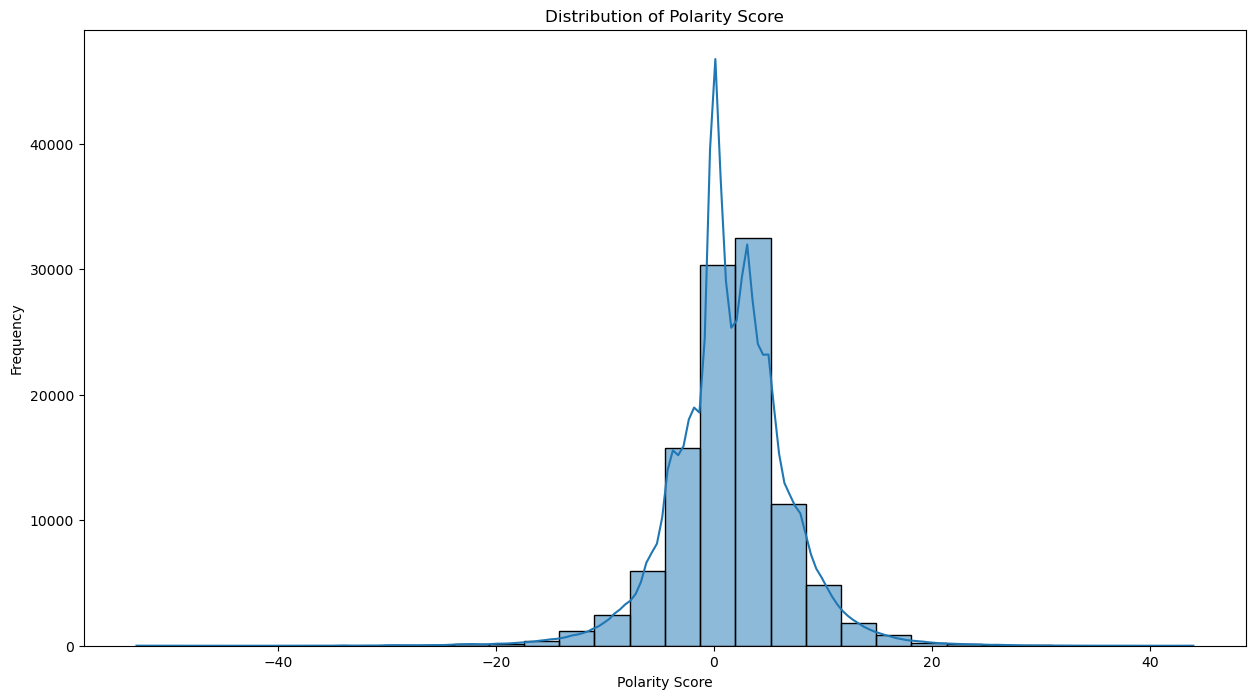

In [34]:
# Menampilkan distribusi polarity_score dengan histogram
plt.figure(figsize=(15, 8))
sns.histplot(clean_data['polarity_score'], bins=30, kde=True)
plt.title('Distribution of Polarity Score')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.show()

Menampilkan diagram lingkaran untuk memudahkan visualisasi pembagian dataset.

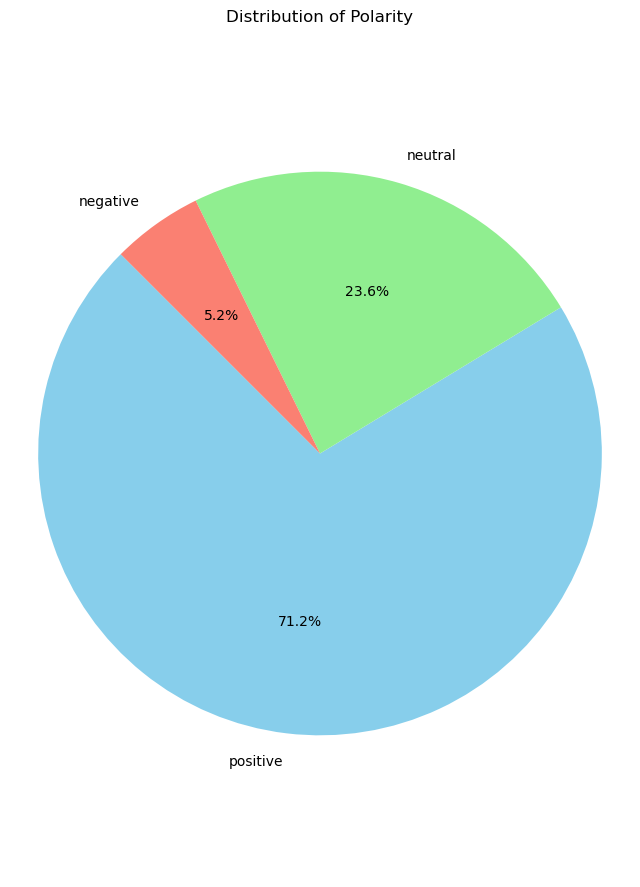

In [37]:
# Menghitung proporsi setiap jenis polaritas
label_polarity = clean_data['polarity'].value_counts()

# Menampilkan visualisasi pie chart untuk distribusi sentimen
plt.figure(figsize=(8, 11))
plt.pie(label_polarity, labels=label_polarity.index, autopct='%1.1f%%', startangle=135, colors=['skyblue', 'lightgreen', 'salmon'])
plt.title('Distribution of Polarity')
plt.axis('equal')
plt.show()

## Word cloud umum

Membuat wordcloud dari dataset tanpa melihat label.

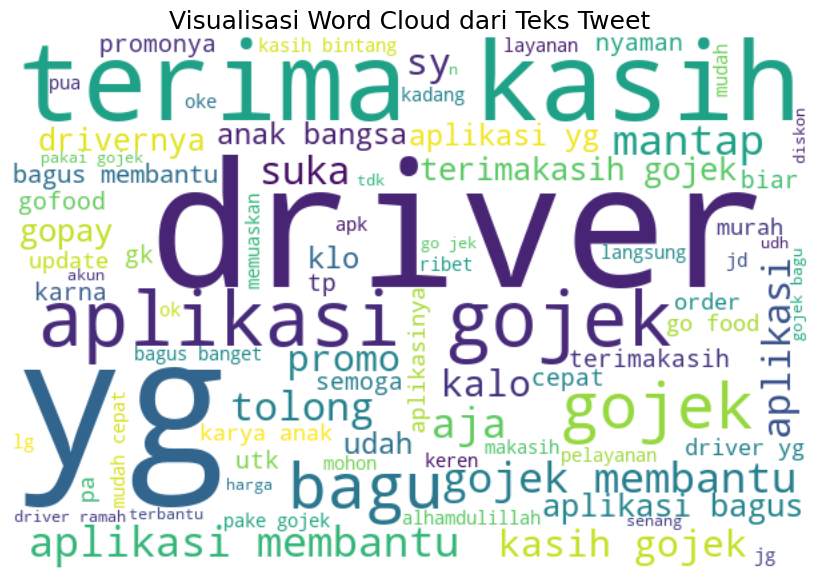

In [41]:
# Menggabungkan semua kata dari tweet menjadi satu string
all_words = ''
for tokens in clean_data['text_stopword']:
    for token in tokens:
        all_words += f' {token}'

# Membuat word cloud dari kumpulan kata
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(all_words)

# Menampilkan visualisasi word cloud
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Visualisasi Word Cloud dari Teks Tweet', fontsize=18)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## Word cloud positive

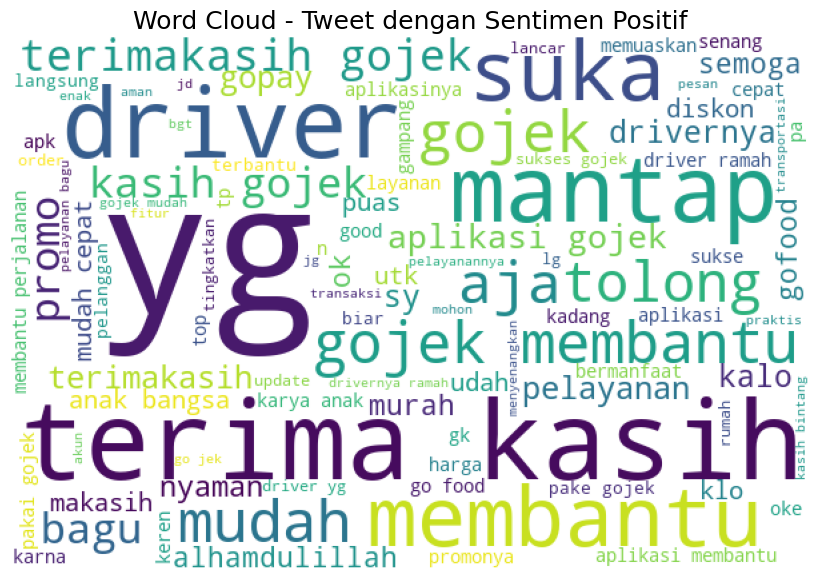

In [42]:
# Mengatur tampilan kolom agar lebar maksimal tampil penuh
pd.set_option('display.max_colwidth', 3000)

# Memilih data dengan sentimen positif
tweet_positif = clean_data[clean_data['polarity'] == 'positive']
tweet_positif = tweet_positif[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
tweet_positif = tweet_positif.sort_values('polarity_score', ascending=False).reset_index(drop=True)
tweet_positif.index += 1  # Penyesuaian indeks agar mulai dari 1

# Menyiapkan string kosong untuk menampung semua kata
kumpulan_kata = ''

# Menggabungkan seluruh kata dari kolom 'text_stopword' menjadi satu string
for kalimat in tweet_positif['text_stopword']:
    for kata in kalimat:
        kumpulan_kata += f' {kata}'

# Membuat word cloud dari kumpulan kata
wordcloud_positif = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(kumpulan_kata)

# Menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(wordcloud_positif)
ax.set_title('Word Cloud - Tweet dengan Sentimen Positif', fontsize=18)
ax.axis('off')
fig.tight_layout(pad=0)
plt.show()

## Word cloud negative

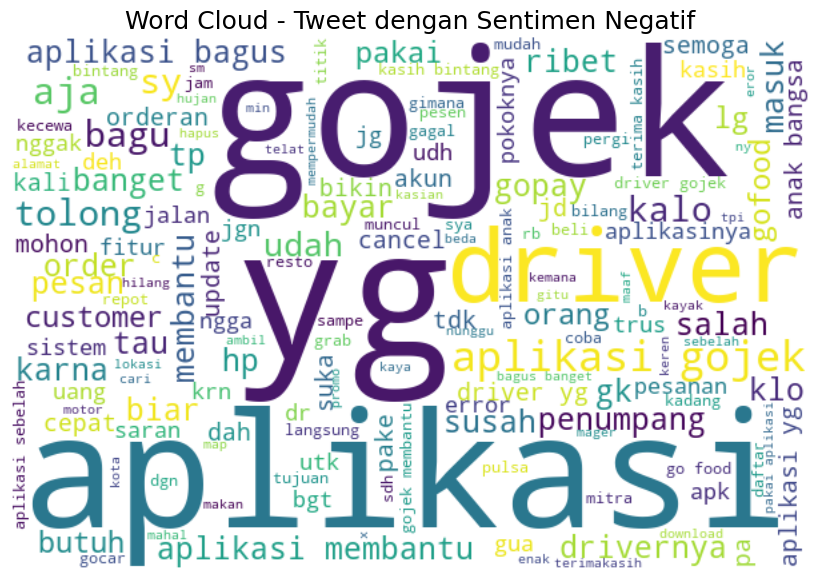

In [44]:
# Mengatur agar kolom teks bisa ditampilkan penuh
pd.set_option('display.max_colwidth', 3000)

# Filter data untuk tweet bernada negatif
tweet_negatif = clean_data[clean_data['polarity'] == 'negative']
tweet_negatif = tweet_negatif[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
tweet_negatif = tweet_negatif.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)
tweet_negatif.index += 1  # Penyesuaian index dimulai dari 1

# Gabungkan semua kata dari tweet negatif
kumpulan_kata_negatif = ''
for kalimat in tweet_negatif['text_stopword']:
    for kata in kalimat:
        kumpulan_kata_negatif += f' {kata}'

# Membuat word cloud dari kumpulan kata negatif
wordcloud_negatif = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10
).generate(kumpulan_kata_negatif)

# Visualisasi word cloud untuk sentimen negatif
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud - Tweet dengan Sentimen Negatif', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud_negatif, interpolation='bilinear')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

## word cloud neutral

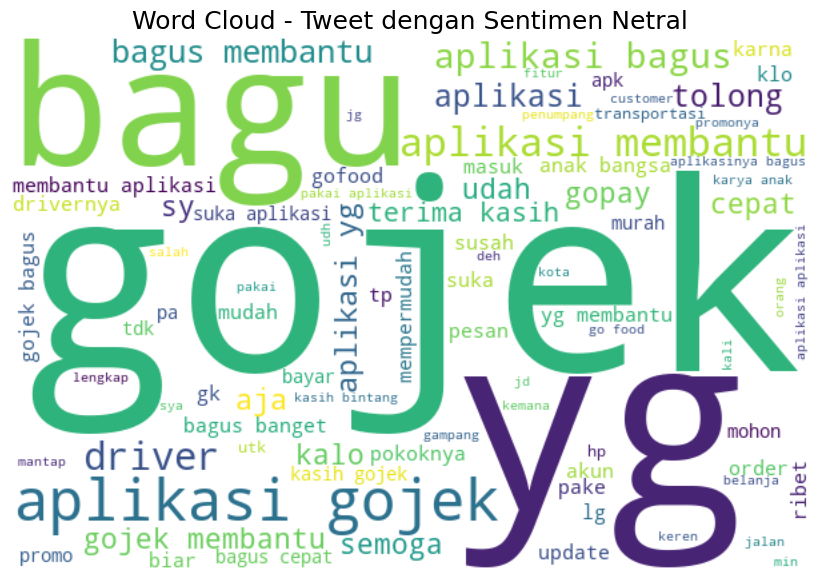

In [47]:
# Menampilkan seluruh isi kolom teks tanpa terpotong
pd.set_option('display.max_colwidth', 3000)

# Menyaring tweet dengan label netral
tweet_netral = clean_data[clean_data['polarity'] == 'neutral']
tweet_netral = tweet_netral[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
tweet_netral = tweet_netral.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)
tweet_netral.index += 1  # Mulai indeks dari 1

# Menggabungkan seluruh kata dari tweet bernada netral
kata_netral = ''
for kalimat in tweet_netral['text_stopword']:
    for kata in kalimat:
        kata_netral += f' {kata}'

# Membuat dan menampilkan Word Cloud untuk tweet netral
wordcloud_netral = WordCloud(
    width=600,
    height=400,
    background_color='white',
    min_font_size=10
).generate(kata_netral)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud - Tweet dengan Sentimen Netral', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud_netral, interpolation='bilinear')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

## Visualisasi dataset

Menampilkan distribusi dari panjang text.

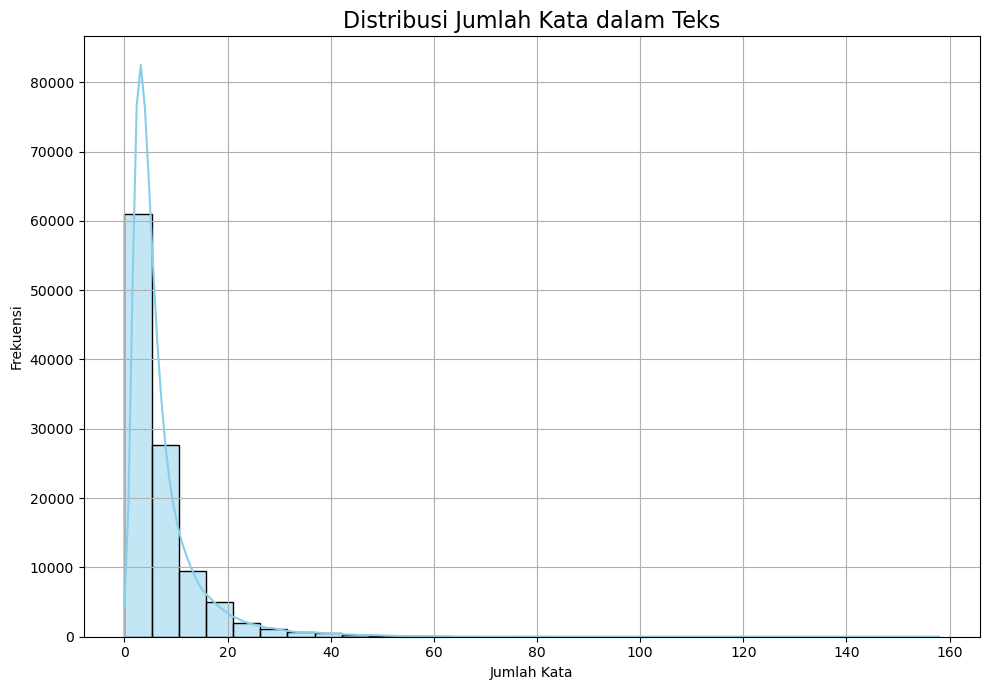

In [48]:
# Visualisasi distribusi jumlah kata dalam setiap tweet
plt.figure(figsize=(10, 7))

# Menghitung jumlah kata per baris pada kolom 'text_akhir'
clean_data['jumlah_kata'] = clean_data['text_akhir'].apply(lambda kalimat: len(kalimat.split()))

# Membuat histogram
sns.histplot(clean_data['jumlah_kata'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Jumlah Kata dalam Teks', fontsize=16)
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.tight_layout()
plt.show()

Menampilkan kata yang paling sering muncul.

C:\Users\aryag\AppData\Local\Temp\ipykernel_1400\4191170717.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Kata', x='Skor_TFIDF', data=top_words_df, palette='viridis')


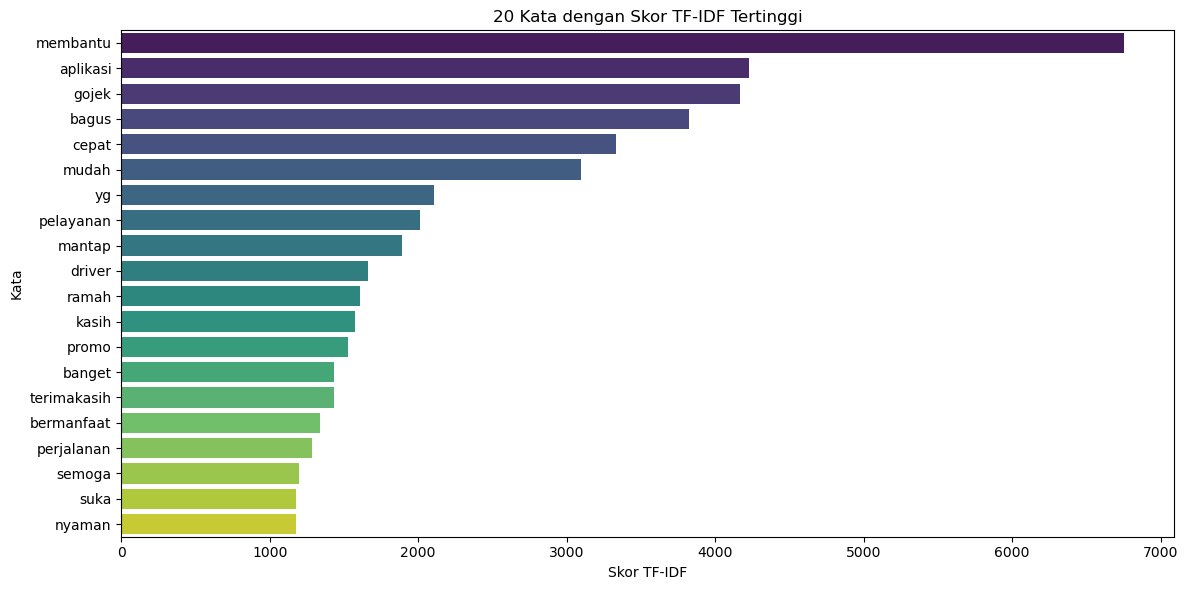

In [51]:
# Atur ukuran visualisasi
plt.figure(figsize=(12, 6))

# Inisialisasi TF-IDF dan batasi jumlah kata unik yang diekstrak
tfidf = TfidfVectorizer(max_features=220000)
matrix = tfidf.fit_transform(clean_data['text_akhir'])

# Hitung total skor TF-IDF setiap kata dari matriks sparse
total_tfidf = matrix.sum(axis=0).A1
term_names = tfidf.get_feature_names_out()

# Buat DataFrame untuk menampung hasil
top_words_df = pd.DataFrame({
    'Kata': term_names,
    'Skor_TFIDF': total_tfidf
})

# Ambil 20 kata dengan skor tertinggi
top_words_df = top_words_df.sort_values(by='Skor_TFIDF', ascending=False).head(20)

# Visualisasi dengan barplot
sns.barplot(y='Kata', x='Skor_TFIDF', data=top_words_df, palette='viridis')
plt.title('20 Kata dengan Skor TF-IDF Tertinggi')
plt.xlabel('Skor TF-IDF')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

## Modeling

Pembuatan model dengan melakukan tiga percobaan skema pelatihan yang berbeda dan dibedakan dengan variasi dari dua kombinasi seperti berikut:

- Model 1
Algoritma Pelatihan: LSTM
Pembagian Data: Training 80, val 10, test 10
- Model 2
Algoritma Pelatihan: CNN
Pembagian Data: Training 70, val 20, test 10
- Model 3
Algoritma Pelatihan: GRU
Pembagian Data: Training 90, val 5, test 5

Kolom text_akhir dijadikan sebagai fitur dan kolom polarity dijadikan sebagai target.

In [55]:
# Mengambil kolom text_akhir dan polarity
X = clean_data['text_akhir']
y = clean_data['polarity']

In [57]:
# Label encoding untuk target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Tokenisasi dan padding
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq)

# Menentukan jumlah fitur dan kelas
max_features = len(tokenizer.word_index) + 1
num_classes = len(set(y_encoded))

In [81]:
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.93:
            print(f"\nVal accuracy telah melebihi 0.93, menghentikan pelatihan pada epoch {epoch+1}")
            self.model.stop_training = True

early_stopping = CustomCallback()

## Model 1 - LSTM

In [84]:
# Split data
X_train_val, X_test_LSTM, y_train_val, y_test_LSTM = train_test_split(X_pad, y_encoded, test_size=0.1, random_state=42)
X_train_LSTM, X_val_LSTM, y_train_LSTM, y_val_LSTM = train_test_split(X_train_val, y_train_val, test_size=2/9, random_state=42)

# One-hot encoding label
y_train_LSTM = to_categorical(y_train_LSTM, num_classes)
y_val_LSTM = to_categorical(y_val_LSTM, num_classes)
y_test_LSTM = to_categorical(y_test_LSTM, num_classes)

# Arsitektur model LSTM
model_LSTM = Sequential([
    Embedding(max_features, 300, input_length=X_pad.shape[1]),
    LSTM(128, return_sequences=True, dropout=0.4, recurrent_dropout=0.4, kernel_regularizer=l2(0.01)),
    LSTM(64, dropout=0.4, recurrent_dropout=0.4, kernel_regularizer=l2(0.01)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_LSTM.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Training
history_LSTM = model_LSTM.fit(
    X_train_LSTM, y_train_LSTM,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_LSTM, y_val_LSTM),
    callbacks=[early_stopping],
    verbose=2
)

# Evaluasi
loss_LSTM, acc_LSTM = model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
print(f"Test Loss: {loss_LSTM:.4f}")
print(f"Test Accuracy: {acc_LSTM:.4f}")

model_LSTM.save('model_LSTM.h5')


C:\Users\aryag\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
591/591 - 1865s - 3s/step - accuracy: 0.8325 - loss: 0.7151 - val_accuracy: 0.9224 - val_loss: 0.2443
Epoch 2/50
591/591 - 1375s - 2s/step - accuracy: 0.9359 - loss: 0.2055 - val_accuracy: 0.9276 - val_loss: 0.2140
Epoch 3/50

Val accuracy telah melebihi 0.93, menghentikan pelatihan pada epoch 3
591/591 - 927s - 2s/step - accuracy: 0.9590 - loss: 0.1457 - val_accuracy: 0.9386 - val_loss: 0.1926
338/338 - 35s - 102ms/step - accuracy: 0.9365 - loss: 0.1949


Test Loss: 0.1949
Test Accuracy: 0.9365


## Model 2 - CNN

In [91]:
# Split data
X_train_val2, X_test_CNN, y_train_val2, y_test_CNN = train_test_split(X_pad, y_encoded, test_size=0.1, random_state=42)
X_train_CNN, X_val_CNN, y_train_CNN, y_val_CNN = train_test_split(X_train_val2, y_train_val2, test_size=2/7, random_state=42)

# One-hot encoding label
y_train_CNN = to_categorical(y_train_CNN, num_classes)
y_val_CNN = to_categorical(y_val_CNN, num_classes)
y_test_CNN = to_categorical(y_test_CNN, num_classes)

# Arsitektur model CNN
model_CNN = Sequential([
    Embedding(max_features, 300, input_length=X_pad.shape[1]),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_CNN.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Training
history_CNN = model_CNN.fit(
    X_train_CNN, y_train_CNN,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_CNN, y_val_CNN),
    callbacks=[early_stopping],
    verbose=2
)

# Evaluasi
loss_CNN, acc_CNN = model_CNN.evaluate(X_test_CNN, y_test_CNN, verbose=2)
print(f"Test Loss: {loss_CNN:.4f}")
print(f"Test Accuracy: {acc_CNN:.4f}")

model_CNN.save('model_CNN.h5')


C:\Users\aryag\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
543/543 - 388s - 715ms/step - accuracy: 0.8614 - loss: 0.3388 - val_accuracy: 0.9198 - val_loss: 0.2026
Epoch 2/50
543/543 - 546s - 1s/step - accuracy: 0.9468 - loss: 0.1360 - val_accuracy: 0.9152 - val_loss: 0.2065
Epoch 3/50
543/543 - 459s - 846ms/step - accuracy: 0.9703 - loss: 0.0777 - val_accuracy: 0.9225 - val_loss: 0.2053
Epoch 4/50
543/543 - 415s - 765ms/step - accuracy: 0.9795 - loss: 0.0546 - val_accuracy: 0.9172 - val_loss: 0.2292
Epoch 5/50
543/543 - 383s - 706ms/step - accuracy: 0.9860 - loss: 0.0384 - val_accuracy: 0.9285 - val_loss: 0.2383
Epoch 6/50
543/543 - 369s - 679ms/step - accuracy: 0.9886 - loss: 0.0307 - val_accuracy: 0.9274 - val_loss: 0.2592
Epoch 7/50
543/543 - 373s - 687ms/step - accuracy: 0.9910 - loss: 0.0254 - val_accuracy: 0.9251 - val_loss: 0.2930
Epoch 8/50
543/543 - 372s - 686ms/step - accuracy: 0.9908 - loss: 0.0247 - val_accuracy: 0.9125 - val_loss: 0.3258
Epoch 9/50
543/543 - 370s - 681ms/step - accuracy: 0.9931 - loss: 0.0190 - val_accu

Test Loss: 0.7367
Test Accuracy: 0.9155


## Model 3 - GRU

In [92]:
# Split data
X_train_val3, X_test_GRU, y_train_val3, y_test_GRU = train_test_split(X_pad, y_encoded, test_size=0.05, random_state=42)
X_train_GRU, X_val_GRU, y_train_GRU, y_val_GRU = train_test_split(X_train_val3, y_train_val3, test_size=5.56/94.44, random_state=42)

# One-hot encoding label
y_train_GRU = to_categorical(y_train_GRU, num_classes)
y_val_GRU = to_categorical(y_val_GRU, num_classes)
y_test_GRU = to_categorical(y_test_GRU, num_classes)

# Arsitektur model GRU
model_GRU = Sequential([
    Embedding(max_features, 300, input_length=X_pad.shape[1]),
    GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
    GRU(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_GRU.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Training
history_GRU = model_GRU.fit(
    X_train_GRU, y_train_GRU,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_GRU, y_val_GRU),
    callbacks=[early_stopping],
    verbose=2
)

# Evaluasi
loss_GRU, acc_GRU = model_GRU.evaluate(X_test_GRU, y_test_GRU, verbose=2)
print(f"Test Loss: {loss_GRU:.4f}")
print(f"Test Accuracy: {acc_GRU:.4f}")

model_GRU.save('model_GRU.h5')


Epoch 1/50

Val accuracy telah melebihi 0.93, menghentikan pelatihan pada epoch 1
755/755 - 1046s - 1s/step - accuracy: 0.8917 - loss: 0.2641 - val_accuracy: 0.9450 - val_loss: 0.1367
169/169 - 12s - 73ms/step - accuracy: 0.9472 - loss: 0.1412


Test Loss: 0.1412
Test Accuracy: 0.9472


## Evaluasi model

In [89]:
results_df = pd.DataFrame({
    'Model': ['LSTM'],
    'Accuracy Train': [history_LSTM.history['accuracy'][-1]
    'Accuracy Test': [acc_LSTM]
})
results_df

SyntaxError: closing parenthesis '}' does not match opening parenthesis '[' on line 3 (740920678.py, line 5)

In [93]:
results_df = pd.DataFrame({
    'Model': ['LSTM', 'CNN', 'GRU'],
    'Accuracy Train': [history_LSTM.history['accuracy'][-1], history_CNN.history['accuracy'][-1],history_GRU.history['accuracy'][-1]],
    'Accuracy Test': [acc_LSTM, acc_CNN,acc_GRU]
})
results_df

,Model,Accuracy Train,Accuracy Test
0,LSTM,0.959021,0.936481
1,CNN,0.999049,0.915463
2,GRU,0.891662,0.947222


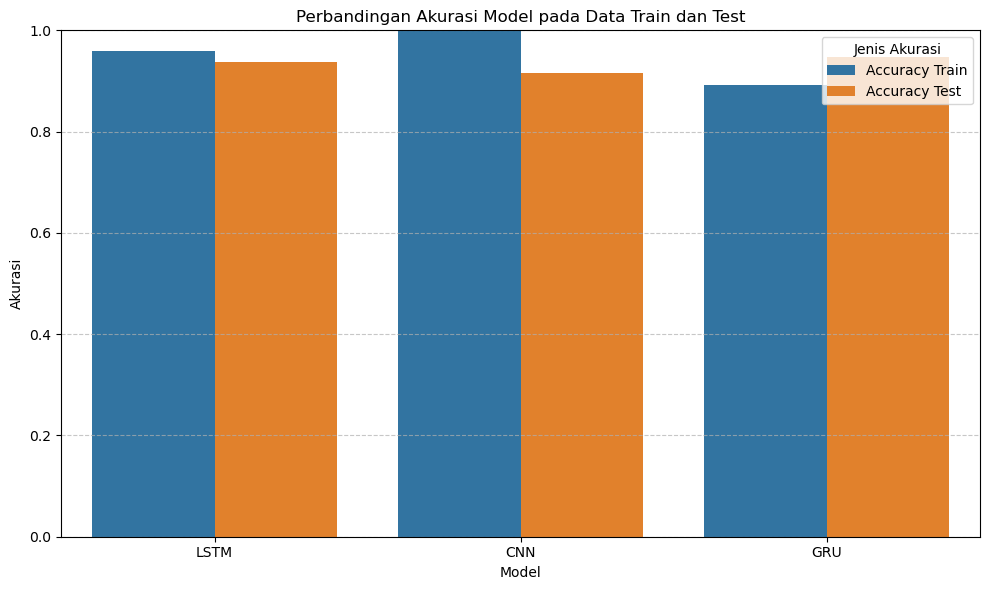

In [94]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.melt(id_vars='Model', var_name='Tipe', value_name='Akurasi'),
            x='Model', y='Akurasi', hue='Tipe')
plt.title('Perbandingan Akurasi Model pada Data Train dan Test')
plt.ylim(0, 1)
plt.legend(title='Jenis Akurasi')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Predict

In [96]:
# Contoh data untuk pengujian prediksi
sample_texts = [
    "layanan gojek sangat memuaskan dan cepat, drivernya ramah",
    "fitur aplikasi error dan susah digunakan, bikin kesel",
    "biasa aja sih, gak terlalu bagus tapi juga gak jelek"
]

# Label asli (ground truth)
label_asli = ["positive", "negative", "neutral"]

# Tokenisasi dan padding pada data uji baru
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_pad = pad_sequences(sample_sequences, maxlen=X_pad.shape[1])

# Prediksi dari masing-masing model
pred_lstm = model_LSTM.predict(sample_pad)
pred_cnn = model_CNN.predict(sample_pad)
pred_gru = model_GRU.predict(sample_pad)

# Ambil indeks dengan nilai probabilitas tertinggi
pred_lstm_labels = np.argmax(pred_lstm, axis=1)
pred_cnn_labels = np.argmax(pred_cnn, axis=1)
pred_gru_labels = np.argmax(pred_gru, axis=1)

# Konversi kembali ke label string
hasil_lstm = label_encoder.inverse_transform(pred_lstm_labels)
hasil_cnn = label_encoder.inverse_transform(pred_cnn_labels)
hasil_gru = label_encoder.inverse_transform(pred_gru_labels)

# Tampilkan hasil prediksi dari ketiga model
for i in range(len(sample_texts)):
    print(f"Teks       : {sample_texts[i]}")
    print(f"Label Asli : {label_asli[i]}")
    print(f"LSTM       : {hasil_lstm[i]}")
    print(f"CNN        : {hasil_cnn[i]}")
    print(f"GRU        : {hasil_gru[i]}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Teks       : layanan gojek sangat memuaskan dan cepat, drivernya ramah
Label Asli : positive
LSTM       : positive
CNN        : positive
GRU        : positive

Teks       : fitur aplikasi error dan susah digunakan, bikin kesel
Label Asli : negative
LSTM       : negative
CNN        : negative
GRU        : negative

Teks       : biasa aja sih, gak terlalu bagus tapi juga gak jelek
Label Asli : neutral
LSTM       : neutral
CNN        : negative
GRU        : neutral

